<a href="https://colab.research.google.com/github/omsoni/model-deployment-ensemble-hf/blob/googlecolab-init/Retail_Chain_Forecast_Model_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 pipreqs -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    RandomForestRegressor
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
retail_data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Model Deployment/SuperKart/SuperKart.csv")

In [ ]:
# Create a copy of the dataframe
dataset = retail_data.copy()

# **Data Overview**

In [ ]:
dataset.shape

(8763, 12)

In [ ]:
dataset.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
dataset['Product_Sugar_Content'] = dataset['Product_Sugar_Content'].astype('category')
product_sugar_content_types = dataset['Product_Sugar_Content'].cat.categories
print(product_sugar_content_types)

Index(['Low Sugar', 'No Sugar', 'Regular', 'reg'], dtype='object')


In [ ]:
dataset["Product_Sugar_Content"].value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2251
No Sugar,1519
reg,108


### Observation on Product_Sugar_Content

The "reg" type seems to be wrongly marked instead of "Regular". I will do some analysis to check the records and update all "reg" to "Regular" to keep data consistent.

In [ ]:
dataset[dataset["Product_Sugar_Content"]=="reg"].head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
43,DR2126,7.82,reg,0.036,Hard Drinks,102.18,OUT002,1998,Small,Tier 3,Food Mart,1443.06
87,FD5746,11.59,reg,0.091,Dairy,145.79,OUT004,2009,Medium,Tier 2,Supermarket Type2,3188.61
118,FD3884,11.72,reg,0.102,Baking Goods,143.79,OUT004,2009,Medium,Tier 2,Supermarket Type2,3175.51
134,FD1368,16.29,reg,0.184,Frozen Foods,217.94,OUT003,1999,Medium,Tier 1,Departmental Store,5726.19
143,FD8450,14.08,reg,0.074,Breads,127.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,3375.71


In [ ]:
reg_marked_data = dataset[dataset["Product_Sugar_Content"]=="reg"]
reg_marked_data["Product_Type"].value_counts()

,count
Product_Type,
Frozen Foods,16
Baking Goods,14
Fruits and Vegetables,13
Snack Foods,11
Canned,11
Meat,9
Soft Drinks,8
Dairy,7
Hard Drinks,6


In [ ]:
dataset[
    (dataset["Product_Sugar_Content"] == "Regular") &
    (dataset["Product_Type"] == "Frozen Foods")
].head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
204,FD5743,11.27,Regular,0.061,Frozen Foods,124.65,OUT004,2009,Medium,Tier 2,Supermarket Type2,2682.62
236,FD4899,10.63,Regular,0.152,Frozen Foods,146.72,OUT004,2009,Medium,Tier 2,Supermarket Type2,2990.81
315,FD3304,14.44,Regular,0.019,Frozen Foods,141.72,OUT004,2009,Medium,Tier 2,Supermarket Type2,3748.31
324,FD3208,13.10,Regular,0.030,Frozen Foods,157.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,3759.71
345,FD3693,15.02,Regular,0.039,Frozen Foods,152.06,OUT001,1987,High,Tier 2,Supermarket Type1,4090.39


**Looks like some products are marked as "reg". Updating them to "Regular"**

In [ ]:
dataset["Product_Sugar_Content"] = dataset["Product_Sugar_Content"].replace("reg", "Regular")

In [ ]:
dataset['Product_Type'] = dataset['Product_Type'].astype('category')
product_types = dataset['Product_Type'].cat.categories
print(product_types)

Index(['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods'],
      dtype='object')


In [ ]:
dataset["Product_Type"].value_counts()

,count
Product_Type,
Fruits and Vegetables,1249
Snack Foods,1149
Frozen Foods,811
Dairy,796
Household,740
Baking Goods,716
Canned,677
Health and Hygiene,628
Meat,618


In [ ]:
dataset['Store_Location_City_Type'] = dataset['Store_Location_City_Type'].astype('category')
store_loc_types = dataset['Store_Location_City_Type'].cat.categories
print(store_loc_types)

Index(['Tier 1', 'Tier 2', 'Tier 3'], dtype='object')


In [ ]:
dataset["Store_Location_City_Type"].value_counts()

,count
Store_Location_City_Type,
Tier 2,6262
Tier 1,1349
Tier 3,1152


In [ ]:
dataset['Store_Size'] = dataset['Store_Size'].astype('category')
store_sizes = dataset['Store_Size'].cat.categories
print(store_sizes)

Index(['High', 'Medium', 'Small'], dtype='object')


In [ ]:
dataset["Store_Size"].value_counts()

,count
Store_Size,
Medium,6025
High,1586
Small,1152


In [ ]:
dataset['Store_Type'] = dataset['Store_Type'].astype('category')
store_types = dataset['Store_Type'].cat.categories
print(store_types)

Index(['Departmental Store', 'Food Mart', 'Supermarket Type1',
       'Supermarket Type2'],
      dtype='object')


In [ ]:
dataset["Store_Type"].value_counts()

,count
Store_Type,
Supermarket Type2,4676
Supermarket Type1,1586
Departmental Store,1349
Food Mart,1152


In [ ]:
dataset.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [ ]:
dataset.isna().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [ ]:
dataset.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [ ]:
# checking for duplicate values
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Id                 8763 non-null   object  
 1   Product_Weight             8763 non-null   float64 
 2   Product_Sugar_Content      8763 non-null   category
 3   Product_Allocated_Area     8763 non-null   float64 
 4   Product_Type               8763 non-null   category
 5   Product_MRP                8763 non-null   float64 
 6   Store_Id                   8763 non-null   object  
 7   Store_Establishment_Year   8763 non-null   int64   
 8   Store_Size                 8763 non-null   object  
 9   Store_Location_City_Type   8763 non-null   object  
 10  Store_Type                 8763 non-null   category
 11  Product_Store_Sales_Total  8763 non-null   float64 
dtypes: category(3), float64(4), int64(1), object(4)
memory usage: 642.9+ KB


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

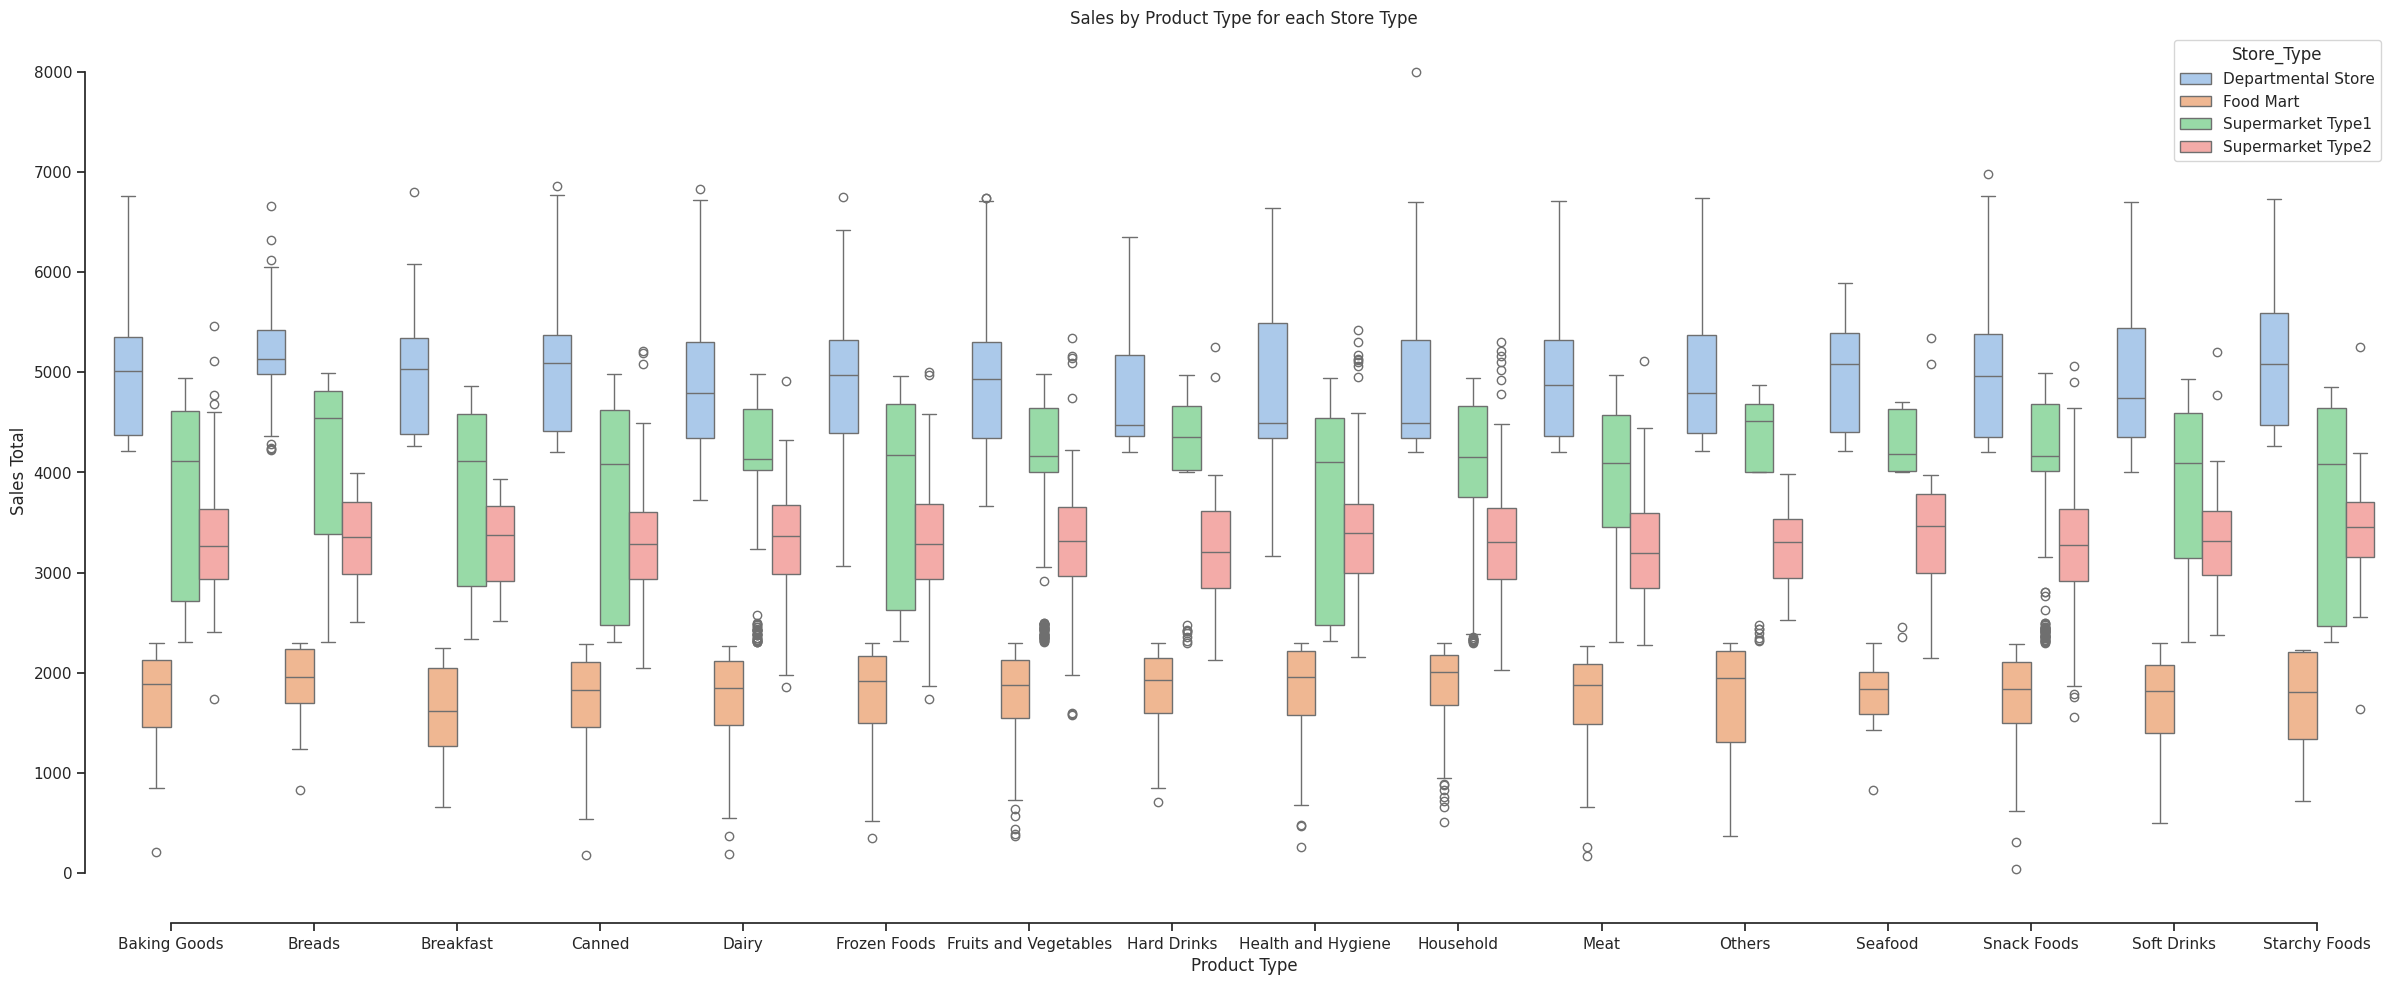

In [ ]:
sns.set_theme(style="ticks", palette="pastel")

import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10)) # Width=12, Height=6
plt.xlabel("Product Type")
plt.ylabel("Sales Total")
plt.title("Sales by Product Type for each Store Type")
plt.xticks(rotation=45) # Options: 0, 45, 90, or 'vertical'
plt.tight_layout() # Ensures labels don't get cut off
# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="Product_Type", y="Product_Store_Sales_Total",
            hue="Store_Type",
            data=dataset)
sns.despine(offset=10, trim=True)

### Observations

The box plot reveals that **store type** is the primary driver of sales variation, with **departmental stores** consistently outperforming other formats across all product categories. While **product type** introduces variability, its impact is secondary compared to store format. Additionally, departmental stores show high variability and upside potential, whereas **food marts** exhibit low but stable performance, indicating structural differences in business models across store types.

Outliers appear in almost all store types and are more frequent in Departmental Stores Supermarket Type1 and are likely caused by  Occasional exceptional sales events such as  Promotions, Seasonal demand, High-demand products

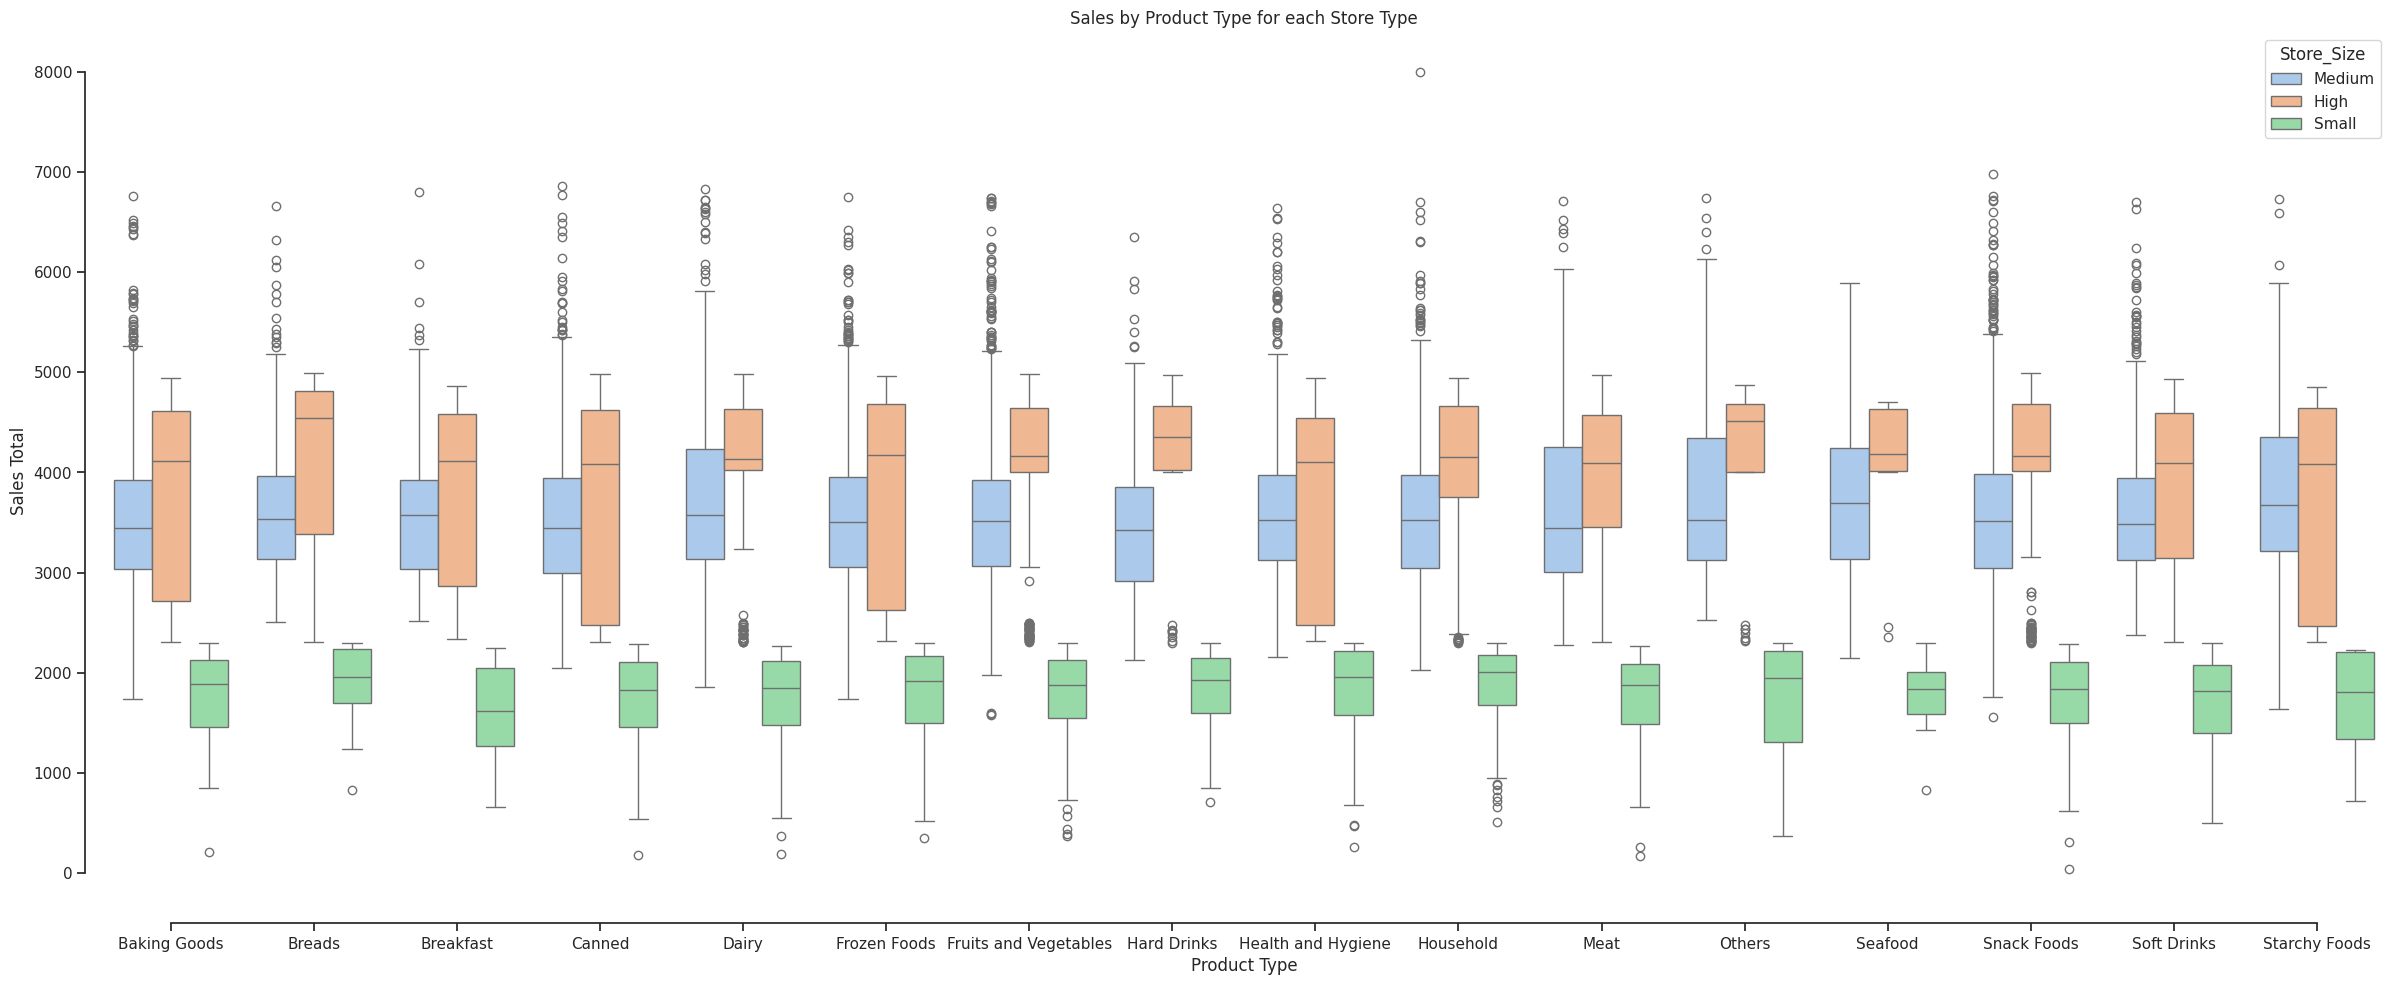

In [ ]:
sns.set_theme(style="ticks", palette="pastel")

import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10)) # Width=12, Height=6
plt.xlabel("Product Type")
plt.ylabel("Sales Total")
plt.title("Sales by Product Type for each Store Type")
plt.xticks(rotation=45) # Options: 0, 45, 90, or 'vertical'
plt.tight_layout() # Ensures labels don't get cut off
# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="Product_Type", y="Product_Store_Sales_Total",
            hue="Store_Size",
            data=dataset)
sns.despine(offset=10, trim=True)

### Observations

**Store size** is a dominant driver of sales across all product categories, with High size stores consistently outperforming others but exhibiting greater variability. **Product type** influences sales within each store segment, but its effect is secondary to store capacity. This indicates that structural factors (store size) have a stronger impact on sales than product-level characteristics.

**Primary Insight and interpretation**

**Store Size** is a strong sales separator across all product types, there is a consistent ranking:
By median sales High size stores show highest sales
Medium-size stores show mid-level sales and Small stores show lowest sales
showing strong monotonic relationship in sales distribution for nearly every product type: Small < Medium < High

* High-size stores have wider IQR (interquartile range)
and more extreme outliers
* Medium-size stores are most stable segment with moderate spread
and fewer extreme outliers consistent medians across product types
* Small stores are consistently constrained
with lowest median sales across all product types
* Product Type has secondary influence
Differences between product types exist but are smaller than store size effect
Slightly higher-performing categories being Household Frozen Foods Snacks Soft Drinks
* Outliers exist across all store sizes - most frequent in High-size stores likely due to promotions, seasonal demand, and high-demand SKUs

In [ ]:
exclude_cols=['Store_Id', 'Product_Id']
target = "Product_Store_Sales_Total"
features = [c for c in dataset.columns if c != target and c not in exclude_cols]

num_cols = [c for c in features if dataset[c].dtype in ['float64', 'int64'] and dataset[c].nunique() > 15]
cat_cols = dataset[features].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical : {num_cols}")
print(f"Categorical: {cat_cols}\n")

Numerical : ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP']
Categorical: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']



### **Normality Test**

A normality check in univariate analysis determine if data follows a normal (Gaussian) distribution, validating the use of parametric statistical tests. It will help with the choice between parametric methods and non-parametric alternatives, ensuring accurate, reliable results, particularly since our dataset is relatively small. We will use following tools for Normality check:

* **normaltest** in scipy.stats package - this function tests the null hypothesis that a sample comes from a normal distribution. It is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality."D'Agostino"

* **Histogram** Best for showing the overall shape, skewness, and modality of the data.

* **Q-Q Plot** Best for detecting deviations from normality at the tails and for smaller datasets.

,Variable,Statistic,P-Value,Normal
0,Product_Weight,0.4614,0.7940,Yes
1,Product_Allocated_Area,1480.8875,0.0000,No
2,Product_MRP,1.9873,0.3702,Yes


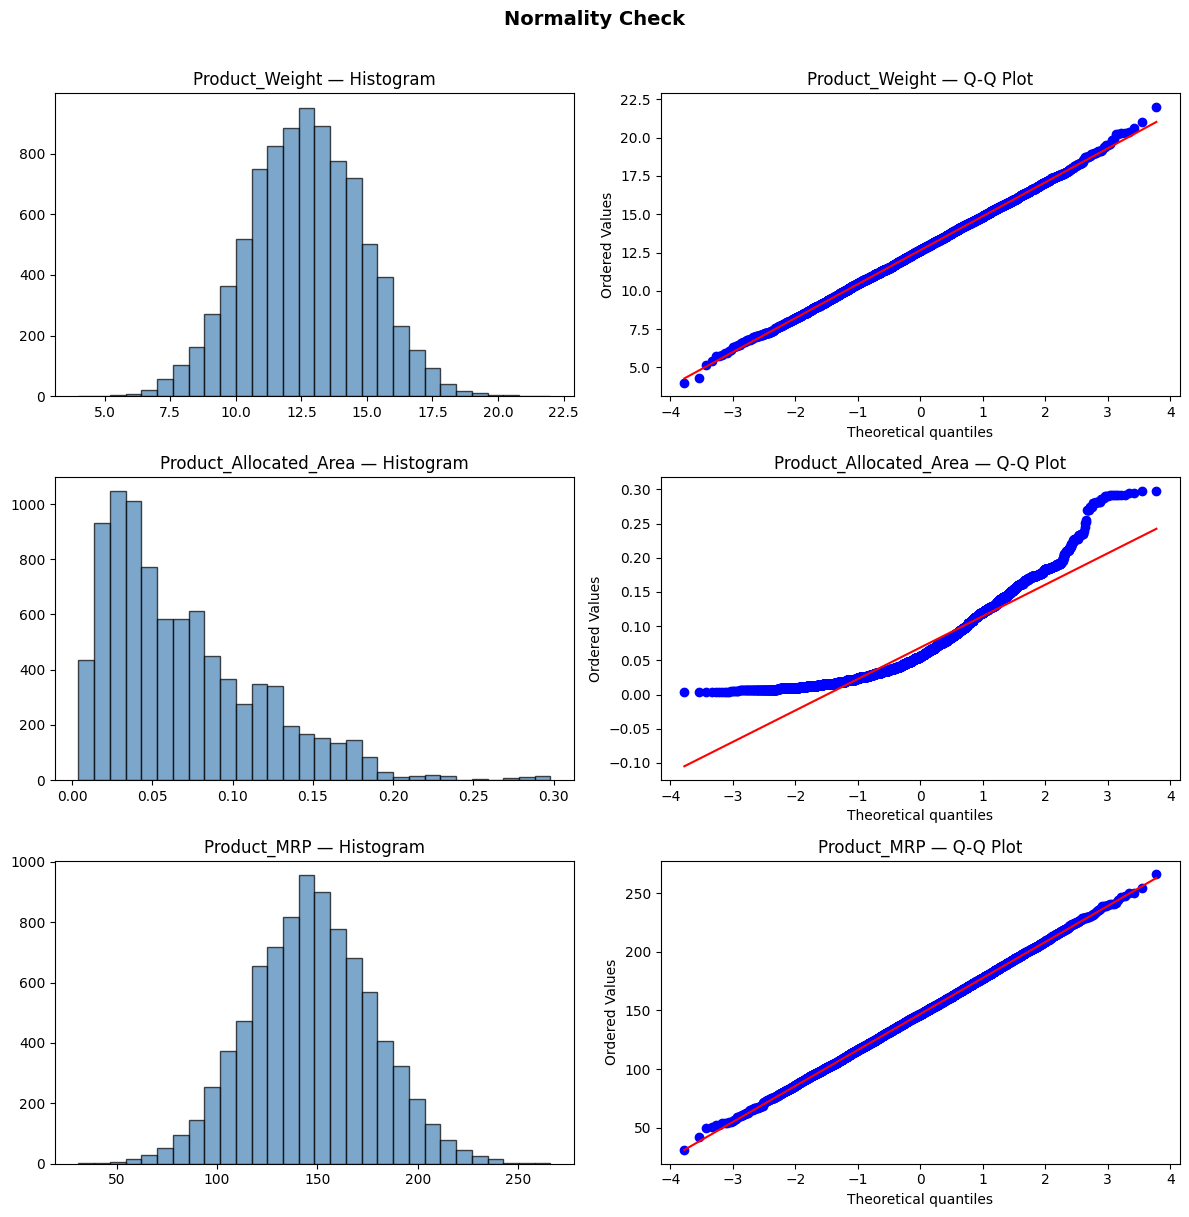

In [ ]:
from scipy.stats import normaltest
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import probplot

def check_normality(df, cols=None):

    # Statistical Tests
    results = []
    for col in cols:
        data = df[col].dropna()
        stat, p = normaltest(data)

        results.append({'Variable': col,
                        'Statistic': round(stat, 4), 'P-Value': round(p, 4),
                        'Normal': 'Yes' if p > 0.05 else 'No'})

    results_df = pd.DataFrame(results)
    display(results_df)

    #Visual Check: Histogram + Q-Q plot per variable
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    axes = axes.reshape(n, 2)  # ensure 2D even for single variable

    for i, col in enumerate(cols):

        data = df[col].dropna()

        # Histogram
        axes[i, 0].hist(data, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
        axes[i, 0].set_title(f'{col} — Histogram')

        # Q-Q Plot
        probplot(data, plot=axes[i, 1])
        axes[i, 1].set_title(f'{col} — Q-Q Plot')

    plt.suptitle("Normality Check", fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return results_df

results = check_normality(dataset, num_cols)

### Observations on Normality Test

Normality tests indicate that Product_Weight and Product_MRP follow approximately normal distributions, while Product_Allocated_Area shows significant deviation from normality, likely due to its skewed nature. However, since the primary models used are tree-based **(XGBoost and Random Forest)**, strict normality assumptions are not required.

## Bivariate Analysis

**Test for multicollinearity**

Multicollinearity is where two or more independent variables are highly correlated.

From earlier analysis:

* Boxplots show skewness and outliers
* Non-linear patterns
* Sales vs MRP is not strictly linear
* Sales vs Store Size is also monotonic

This means relationships are not purely linear

Spearman correlation was preferred over Pearson correlation due to the presence of non-linear and monotonic relationships in the dataset, as well as the existence of outliers. Spearman correlation provides a more robust measure of association under these conditions. Pearson correlation was also computed for comparison to assess linear relationships.

In [ ]:
## Plot Sales with Store Size for Normal Distribution Columns
corr_matrix = dataset.corr(numeric_only=True)

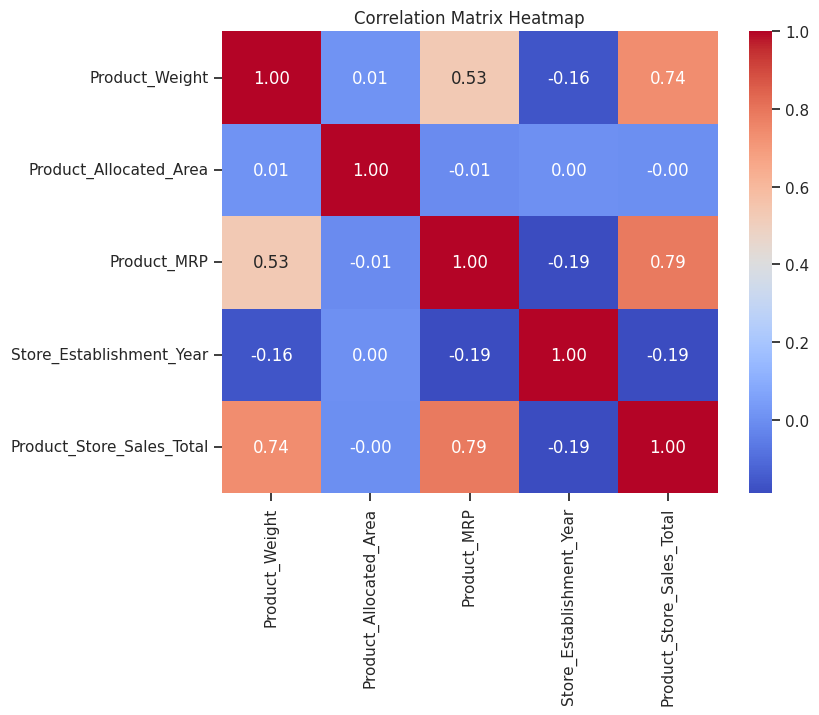

In [ ]:
## Plot Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
## Spearman Rank-Order Correlation for Non-Linear Distribution Columns
spearman_corr = dataset.corr(method='spearman',numeric_only=True)

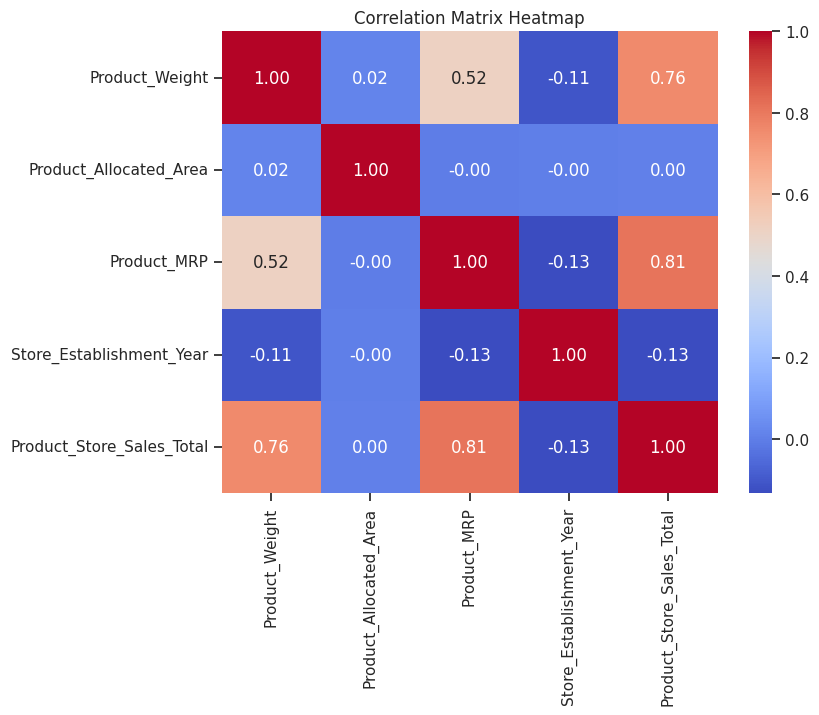

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
## scatterplots

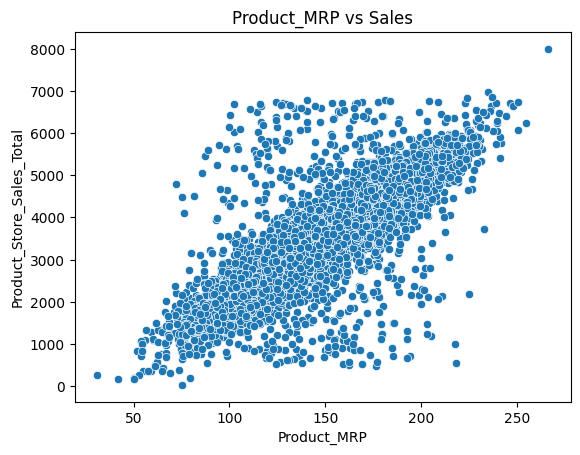

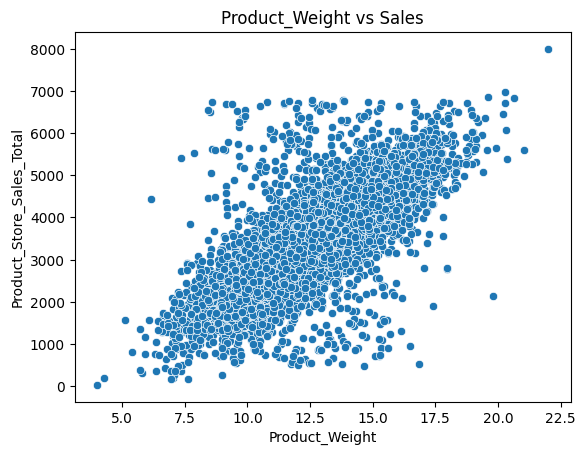

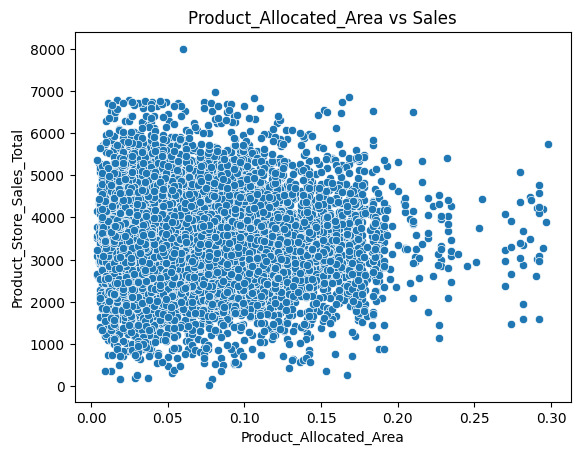

In [ ]:
features = ['Product_MRP', 'Product_Weight', 'Product_Allocated_Area']

for col in features:
    plt.figure()
    sns.scatterplot(x=col, y='Product_Store_Sales_Total',  data=dataset)
    plt.title(f'{col} vs Sales')
    plt.show()

## Observations from Scatterplots

* **Product MRP and Sales** have a strong correlation with strong positive direction, linear form and tight clustering of the data points.
* **Product Weight and Sales** also show a strong correlation with strong positive direction, linear form and tight clustering (although relatively less than first plot)
* **Allocated Area vs Sales** show little correlation.


<Axes: xlabel='Product_MRP', ylabel='Product_Store_Sales_Total'>

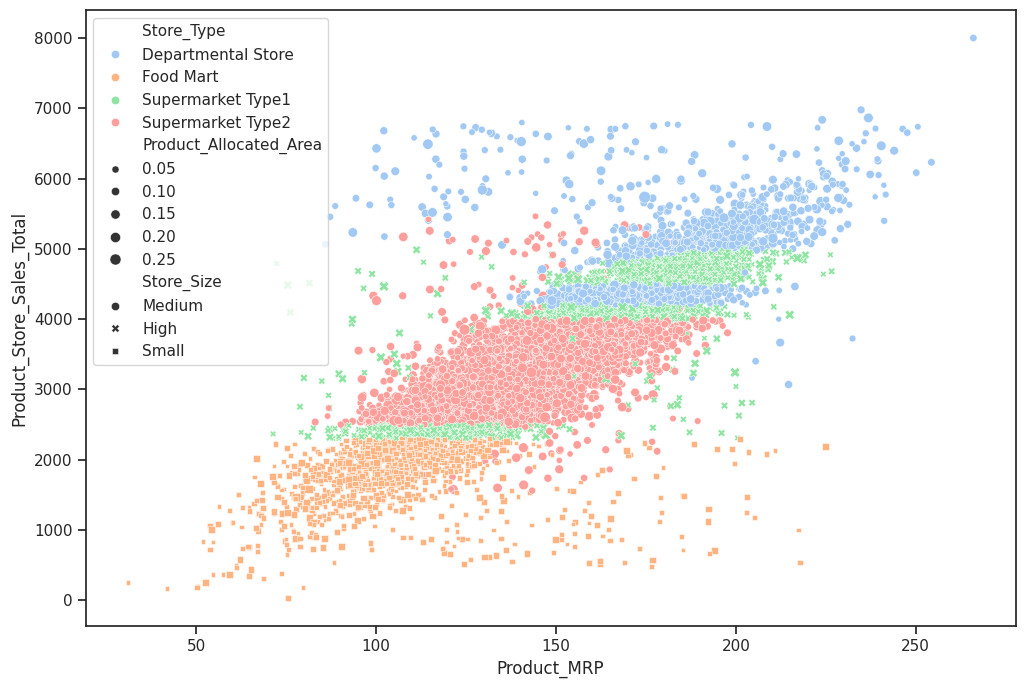

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Product_MRP',
    y='Product_Store_Sales_Total',
    hue='Store_Type',
    style='Store_Size',
    size='Product_Allocated_Area',
    data=dataset
)

### Observations

Looking at the scatter plot, here are the key insights:
**Store Type** drives sales tiers the most. The four store types form clearly separated horizontal bands, meaning store type is a stronger predictor of sales than any other variable shown:

* **Product MRP** has a consistent positive relationship with sales across all store types
* Every band slopes upward left to right. Higher MRP products generate more revenue regardless of store type, which makes sense since
* **Product_Store_Sales_Total** is a revenue metric (units × price). This will likely make **Product_MRP** the most important numeric feature in your model.
* Product Allocated Area adds a secondary signal within each band with lLarger dots (higher allocated display area) tend to sit toward the upper edge of each store type's band. This suggests more shelf space modestly lifts sales within the same store type — a useful but weaker signal compared to MRP.

* **Store Size** is inconsistent across store types High-size stores (× markers) appear mainly in green (Supermarket Type1) and do sit toward the upper edge of that band. However, Medium stores dominate the blue band, making Store Size harder to use as a standalone predictor — its effect is conditional on Store Type.
**Food Mart** shows the highest within-band variance

The clean band separation confirms **Store_Type** is the most influential categorical feature. The MRP slope within each band confirms a strong numeric signal.

## Observations on Dataset


| Property        | Value                         |
| --------------- | ----------------------------- |
| Rows            | 8,763                         |
| Columns         | 13                            |
| Target Variable | Product_Store_Sales_Total     |
| Problem Type    | Regression (Sales Prediction) |

* Mixed dataset: numeric + categorical + ID columns
* Dataset independent variables (IVs) shows Non-linearity with Mixed features
* Interactions among IVs - price x store type x tier
* The dataset is a strong candidate for tree-based ML models

#### **Target Variable Analysis**

| Metric  | Value   |
| ------- | ------- |
| Mean    | 3464.00 |
| Median  | 3452.34 |
| Std Dev | 1065.63 |
| Min     | 33.00   |
| Max     | 8000.00 |

### **Insights**

**Target variable**
* Mean ≈ Median.  Dataset distribution is fairly symmetric
* Large range (33 to 8000) means high variability in sales
* High std dev means strong spread in store-product performance

**Dataset**

* Dataset is clean, structured, and ML-ready
* High potential for non-linear interactions
* Strong candidate for tree-based ML models - best modeled using tree-based ensemble models due to the presence of mixed data types, non-linear relationships, strong interaction effects, and heterogeneous patterns across stores and products. Additionally, the data contains outliers and does not satisfy linear model assumptions such as normality and linearity. Tree-based models like **XGBoost** and **Random Forest** effectively handle these complexities by capturing non-linear patterns, interactions, and segment-level variations without requiring extensive preprocessing, making them an ideal choice for this sales forecasting problem.

## Feature Selection

In [ ]:
# 1. Pearson Correlation (numerical features)
results = []
for col in num_cols:
    corr = dataset[[col, target]].dropna().corr().iloc[0, 1]
    results.append({'Feature': col, 'Method': 'Pearson Correlation',
                    'Score': round(abs(corr), 4)})

results_df = pd.DataFrame(results)
print(results_df)

                  Feature               Method   Score
0          Product_Weight  Pearson Correlation  0.7380
1  Product_Allocated_Area  Pearson Correlation  0.0009
2             Product_MRP  Pearson Correlation  0.7880


Feature relevance was evaluated using:

* **Pearson Correlation** for numerical variables
* **ANOVA (F-test)** for categorical variables

This combined approach ensures:
* Linear relationships are captured for numeric features
* Group-level variance is assessed for categorical features

**Key Observations**

* Product_MRP is the strongest numerical predictor of sales
* Product_Weight also shows high correlation (may capture product category/size effects)
* Product_Allocated_Area shows near-zero linear correlation, suggesting:
1) Possible non-linear relationship
2) Interaction effects with store characteristics

In [ ]:
# 2. ANOVA F-score (categorical features vs continuous target)
from scipy.stats import f_oneway
for col in cat_cols:
    groups = [dataset[target][dataset[col] == val].dropna() for val in dataset[col].unique()]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        f_stat, _ = f_oneway(*groups)
        results.append({'Feature': col, 'Method': 'ANOVA F-score',
                        'Score': round(f_stat, 4)})
results_df = pd.DataFrame(results)
print(results_df)

                    Feature               Method      Score
0            Product_Weight  Pearson Correlation     0.7380
1    Product_Allocated_Area  Pearson Correlation     0.0009
2               Product_MRP  Pearson Correlation     0.7880
3     Product_Sugar_Content        ANOVA F-score     2.3161
4              Product_Type        ANOVA F-score     1.3642
5                Store_Size        ANOVA F-score  2847.4127
6  Store_Location_City_Type        ANOVA F-score  7561.6076
7                Store_Type        ANOVA F-score  6193.7856


### **Key Observations**

Feature selection analysis indicates that store-level attributes and product pricing are the primary drivers of sales, while product-level categorical features have weaker standalone influence. However, all features were retained for modeling to allow advanced algorithms to capture non-linear relationships and interactions, thereby maximizing predictive performance.

**Strong Predictors**
* Product_MRP
* Product_Weight
* Store_Location_City_Type
* Store_Type
* Store_Size

**Weak Predictors**
* Product_Allocated_Area
* Product_Type
* Product_Sugar_Content

No features were dropped during feature selection.
* Even low-scoring features may contribute to model performance through interactions
* Tree-based ensemble models are robust to irrelevant or weak features
* Retaining all features ensures maximum information is available for learning complex patterns



### **Shelf Space Analysis**

We know shelf space is very important in retail. But earlier analysis shows no linear correlation with sales (Product_Allocated_Area has Pearson Correlation of 0.0009).


In [ ]:
shelf_space_dataset = dataset[['Product_Allocated_Area', 'Product_Store_Sales_Total']]

In [ ]:
shelf_space_dataset['Area_Bin'] = pd.qcut(shelf_space_dataset['Product_Allocated_Area'], q=5)
shelf_space_dataset.groupby('Area_Bin')['Product_Store_Sales_Total'].mean()

,Product_Store_Sales_Total
Area_Bin,
"(0.003, 0.027]",3444.413635
"(0.027, 0.045]",3444.738758
"(0.045, 0.071]",3487.819374
"(0.071, 0.109]",3519.046188
"(0.109, 0.298]",3426.548624


Beyond optimal point extra space does not improve sales and may even reduce sales slightly

The relationship between product allocated area and sales is non-linear. Sales increase with shelf space up to an optimal range, after which further increases lead to diminishing or negative returns. This explains the near-zero Pearson correlation, as the relationship is not linear but follows an inverted U-shaped pattern.

Shelf space should be optimized rather than maximized. Allocating moderate display space (approximately 0.07 to 0.11 range) yields the highest sales, while excessive allocation may lead to inefficiencies and reduced performance.

Shelf space does impact sales, but not linearly. There is an optimal allocation range, beyond which increasing space leads to diminishing or negative returns.

## Model Selection

Comparing the given list of ML models choices:

**Decision Tree** are too simple and overfits easily for this use case
**Bagging** less impactful standalone, while Bagging reduces variance
it does not fix bias and feature interactions are hit or miss (some tree capture it other don't)
**Gradient Boosting** is very similiar to XGBoost
**AdaBoost** is sensitive to noise, It is harder to justify vs XGBoost

**XGBoost**

XGBoost works very well for our dataset:

* Mixed features (categorical + numeric)
* Handles Non-linear relationships
* Handles Feature Interactions (e.g. Product_MRP + Store_Type + City_Tier)
* Works well for Moderate size tabular data as in our case
* XGBoost includes L1 & L2 regularization to handle noise and skewed distributions

**Random Forest** is
* Robust
* Handles non-linearity
* Gives good performance
* Captures some interactions

### **First model**
We will use **XGBoost** for this assignment. There are however few things to consider its shortcomings in mind:

**Challenges with XGBoost**

* Does not work well with very small dataset - we are ok there with ~9K records
* It is not very fast so does not work well with real-time ultra-low latency needed - We don't necessarily need ultra-low latency but this can be a concern because the model will be exposed as API endpoint
* Does not work well with time-series with strong temporal patterns - our dataset is not temporal.

### **Second model**


I selected **Random Forest** with **XGBoost** to compare bagging and boosting ensemble techniques. Random Forest serves as a strong baseline by reducing variance through parallel tree aggregation, while XGBoost improves predictive performance by sequentially minimizing residual errors. Their comparison will help evaluate trade-offs between model complexity, accuracy, and interpretability.


# **Data Preprocessing**

In [ ]:
# Define predictor matrix (X) using selected numeric and categorical features
X = dataset[num_cols + cat_cols]

# Define target variable
y = dataset[target]

In [ ]:
# Split the dataset into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
)

# **Model Building**

### Model Evaluation

My model evaluation framework assesses performance on both training and test datasets using multiple complementary metrics, including **MAE, RMSE, R-Square, and MAPE**, along with **visual diagnostics** such as actual vs. predicted scatter plots and error comparisons.

* **MAE (Mean Absolute Error)** measures the average magnitude of errors in predictions
* **RMSE** (Root Mean Squared Error) penalizes larger errors more heavily, highlighting model sensitivity to outliers
* **R-Square** (Coefficient of Determination) indicates how well the model explains variance in the target variable
* **MAPE (Mean Absolute Percentage Error)** provides a business-friendly interpretation of error in percentage terms

By evaluating both training and test performance, the approach also identifies overfitting or underfitting, using the R-Square gap as a key indicator.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Evaluates a regression model on both train and test sets and returns a summary DataFrame
def evaluate_plot_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    splits = {"Train": (X_train, y_train), "Test": (X_test, y_test)}
    results = {}

    plt.figure()

    for split_name, (X, y) in splits.items():
        preds = model.predict(X)
        mae   = mean_absolute_error(y, preds)
        rmse  = np.sqrt(mean_squared_error(y, preds))
        r2    = r2_score(y, preds)
        mape  = np.mean(np.abs((y - preds) / np.where(y == 0, 1, y))) * 100

        results[split_name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape}

        plt.scatter(y, preds, label=model_name)
        plt.legend()
        plt.xlabel(split_name + " Actual")
        plt.ylabel(split_name + "Predicted")
        plt.title("Model Comparison - " + split_name)
        plt.show()


    labels = ['Train', 'Test']
    values = [results['Train']['MAPE (%)'], results['Test']['MAPE (%)']]

    plt.bar(labels, values)
    plt.axhline(0)  # zero bias line
    plt.title("MPE Comparison (Train vs Test)")
    plt.ylabel("MPE (%)")
    plt.show()

    df = pd.DataFrame(results).T.round(4)
    print(f"\n{'*'*50}")
    print(f"  {model_name}")
    print(f"{'*'*50}")
    print(df.to_string())
    print(f"  Overfit gap (R2): {results['Train']['R2'] - results['Test']['R2']:.4f}")
    return df

In [ ]:
# XGBoost — uses OrdinalEncoder preprocessor (treePreprocess)
xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(Xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('clf',
                 XGB...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=400, n_jobs=-1,
                              num_parallel_tree=None, random_state=42, ...))])

### Randaom Forrest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfc_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ))
])

rfc_model.fit(Xtrain, ytrain)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('clf',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=50,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

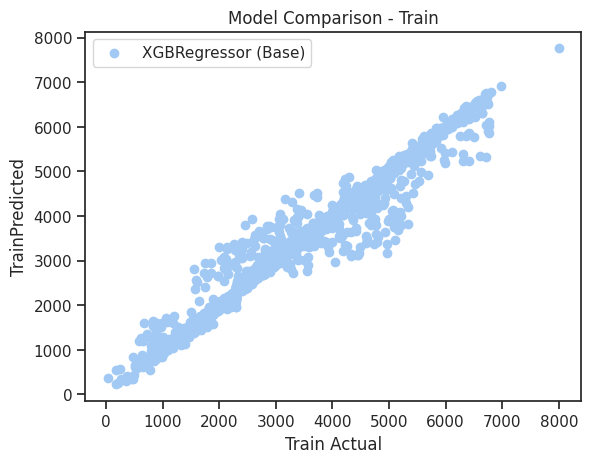

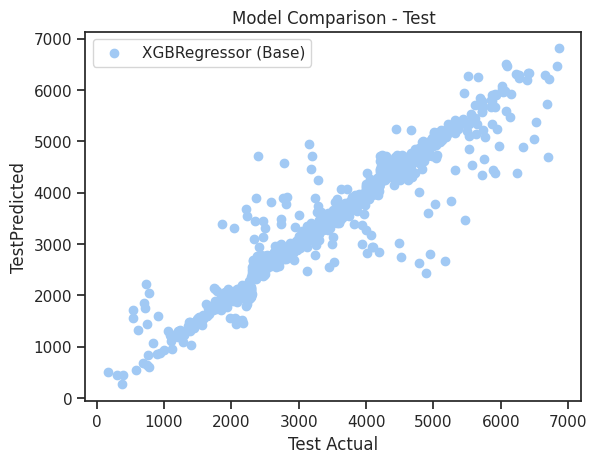

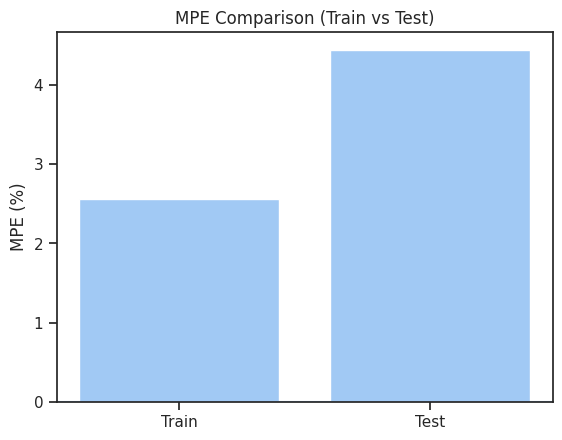


**************************************************
  XGBRegressor (Base)
**************************************************
            MAE      RMSE      R2  MAPE (%)
Train   69.2146  165.0408  0.9760    2.5577
Test   121.3185  287.1975  0.9277    4.4442
  Overfit gap (R2): 0.0483


In [ ]:
# Evaluate base models
xgb_base_results = evaluate_plot_model(xgb_model, Xtrain, Xtest, ytrain, ytest, "XGBRegressor (Base)")

## Observations for XGBRegressor

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| MAE    | 68.86  | 122.73 |
| RMSE   | 163.52 | 290.65 |
| R-Sq     | 0.9764 | 0.9260 |
| MAPE   | 2.53%  | 4.50%  |

**Insights**

* Model shows moderate overfit with R-Sq gap: 0.0505
* Very strong predictive power
* However, noticeable overfitting on training data


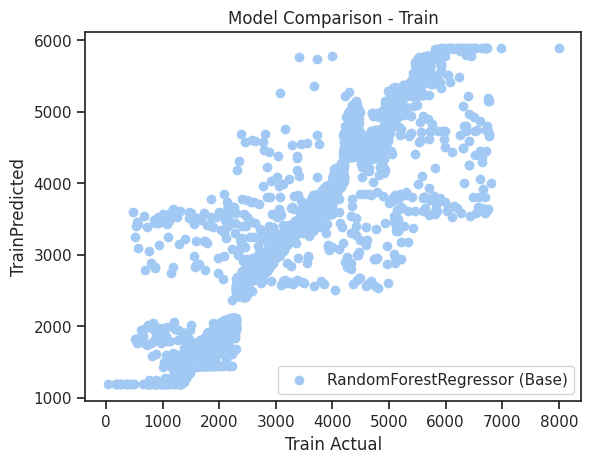

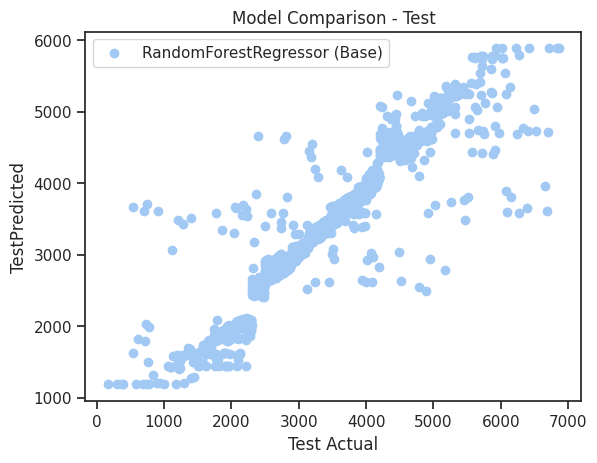

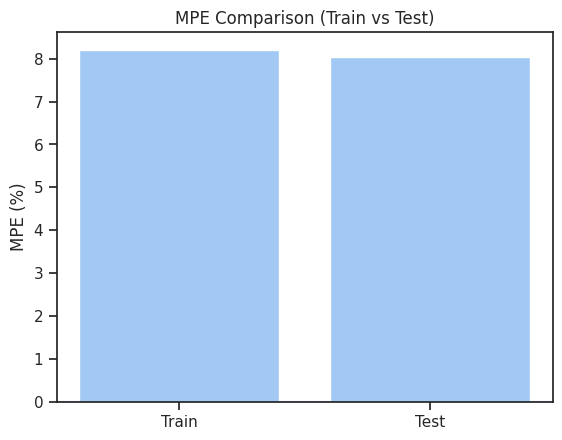


**************************************************
  RandomForestRegressor (Base)
**************************************************
            MAE      RMSE      R2  MAPE (%)
Train  184.8645  412.0950  0.8503    8.2071
Test   190.0191  409.5146  0.8530    8.0340
  Overfit gap (R2): -0.0028


In [ ]:
rfc_base_results = evaluate_plot_model(rfc_model, Xtrain, Xtest, ytrain, ytest, "RandomForestRegressor (Base)")

### Observations for Random Forrest Regressor

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| MAE    | 184.86 | 190.02 |
| RMSE   | 412.10 | 409.51 |
| R-Sq     | 0.8503 | 0.8530 |
| MAPE   | 8.21%  | 8.03%  |

With R-Sq gap of -0.0028, the model performance scores show no overfitting

**Insight**
* Stable generalization
* Significantly lower predictive accuracy than XGBoost

# **Model Performance Improvement - Hyperparameter Tuning**

## XGBRegressor -  Hyperparameter Tunning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
  'clf__n_estimators':      [300, 500, 700], # the number of trees or base estimators
  'clf__learning_rate':     [0.01, 0.05, 0.1], # learning rates for training
  'clf__max_depth':         [4, 6, 8],
  'clf__subsample':         [0.7, 0.8, 0.9],
  'clf__colsample_bytree':  [0.6, 0.8, 1.0],
  'clf__min_child_weight':  [1, 5, 10],
  'clf__gamma':             [0, 0.1, 0.3],
  'clf__reg_alpha':         [0, 0.1, 1.0],   # L1
  'clf__reg_lambda':        [1.0, 2.0, 5.0], # L2
}

xgb_search = RandomizedSearchCV(
  estimator=xgb_model,
  param_distributions=xgb_param_grid,
  n_iter=40,
  scoring='neg_root_mean_squared_error',
  cv=5,
  random_state=42,
  n_jobs=1, # Changed from -1 to 1 to fix the KeyError
  verbose=1
)
xgb_search.fit(Xtrain, ytrain)
xgb_tuned = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params: {'clf__subsample': 0.7, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 700, 'clf__min_child_weight': 10, 'clf__max_depth': 8, 'clf__learning_rate': 0.01, 'clf__gamma': 0.1, 'clf__colsample_bytree': 1.0}


In [ ]:
## RandomForestRegressor -  Hyperparameter Tunning

In [ ]:
rfc_param_grid = {
    'clf__n_estimators':   [200, 400, 600], #the number of trees or base estimators
    'clf__max_depth':      [8, 12, 16, None],
    'clf__min_samples_leaf': [10, 30, 50],
    'clf__min_samples_split': [2, 10, 20],
    'clf__max_features':   ['sqrt', 'log2', 0.5],
    'clf__bootstrap':      [True, False],
}

rfc_search = RandomizedSearchCV(
    estimator=rfc_model,
    param_distributions=rfc_param_grid,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

In [ ]:
rfc_search.fit(Xtrain, ytrain)
rfc_tuned = rfc_search.best_estimator_
print("Best RFC params:", rfc_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RFC params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 10, 'clf__max_features': 0.5, 'clf__max_depth': None, 'clf__bootstrap': False}


# **Model Performance Comparison, Final Model Selection, and Serialization**

### Evaluation Matric

This analysis compares the performance of **XGBoost** and **Random Forest** across Base models and Hyperparameter-tuned models

Evaluation metrics is as described in section **Model Evaluation** earlier:

* MAE (Mean Absolute Error)
* RMSE (Root Mean Squared Error)
* R-Sqaure (Explained Variance)
* MAPE (%)
* Overfitting gap (Train R-Sqaure - Test R-Sqaure)

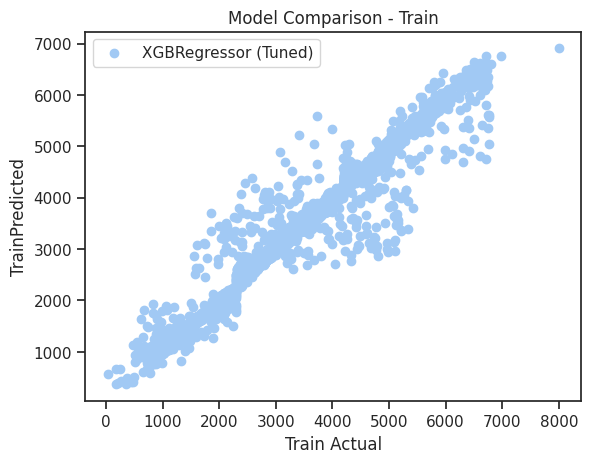

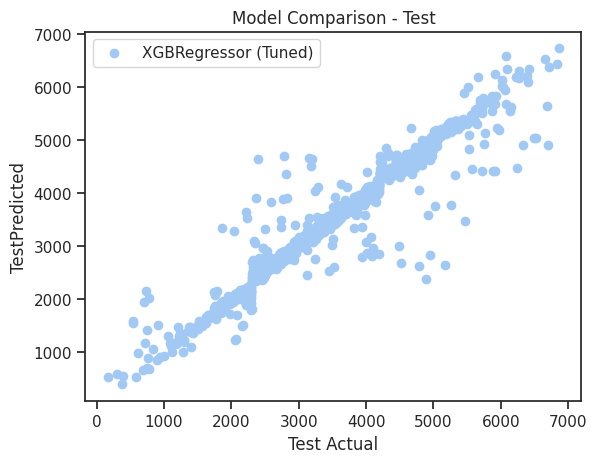

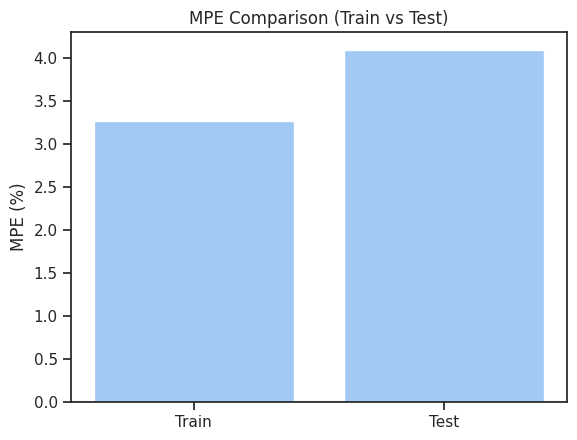


**************************************************
  XGBRegressor (Tuned)
**************************************************
            MAE      RMSE      R2  MAPE (%)
Train   85.6683  221.7968  0.9566    3.2730
Test   112.4960  280.9774  0.9308    4.0986
  Overfit gap (R2): 0.0258


In [ ]:
xgb_tuned_results = evaluate_plot_model(xgb_tuned, Xtrain, Xtest, ytrain, ytest, "XGBRegressor (Tuned)")

### Observations on Tuned XGBRegressor

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| MAE    | 85.68  | 112.43 |
| RMSE   | 221.86 | 280.91 |
| R-Sq     | 0.9566 | 0.9308 |
| MAPE   | 3.27%  | 4.10%  |

**Insights**
* Overfitting: R-Square gap is 0.0258 (improved generalization)
* Slight reduction in training performance
* Improved test performance and generalization
* **Best overall model**

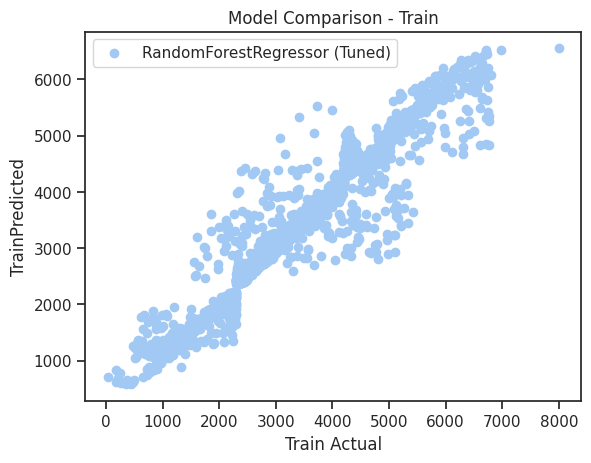

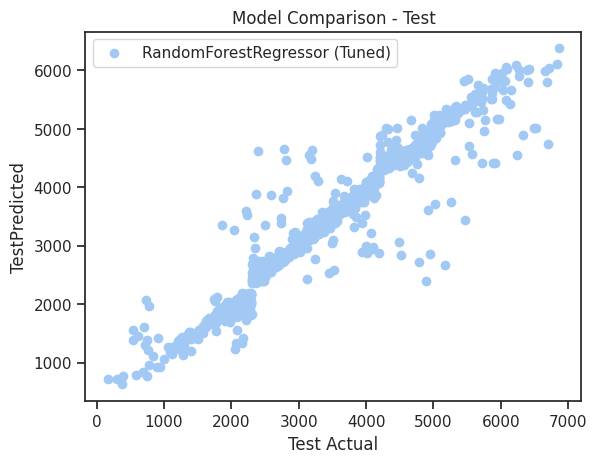

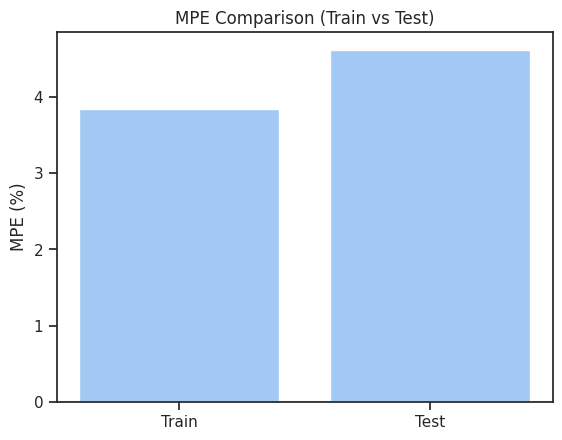


**************************************************
  RandomForestRegressor (Tuned)
**************************************************
            MAE      RMSE      R2  MAPE (%)
Train   94.9364  235.2778  0.9512    3.8381
Test   123.1108  285.8899  0.9284    4.6206
  Overfit gap (R2): 0.0228


In [ ]:
rfc_tuned_results  = evaluate_plot_model(rfc_tuned,  Xtrain, Xtest, ytrain, ytest, "RandomForestRegressor (Tuned)")

### Observations on Tuned Random Forrest Regressor

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| MAE    | 99.58  | 128.47 |
| RMSE   | 238.86 | 289.54 |
| R-sq     | 0.9497 | 0.9265 |
| MAPE   | 4.06%  | 4.89%  |

**Insights**
* Overfitting: R-Sqaure gap: 0.0232 (well-controlled)
* Significant improvement over base model
* Still slightly behind tuned XGBoost in accuracy

In [ ]:
# Side-by-side summary table
summary = pd.concat([
    xgb_base_results.loc[["Test"]].rename(index={"Test": "XGB Base"}),
    xgb_tuned_results.loc[["Test"]].rename(index={"Test": "XGB Tuned"}),
    rfc_base_results.loc[["Test"]].rename(index={"Test": "RFC Base"}),
    rfc_tuned_results.loc[["Test"]].rename(index={"Test": "RFC Tuned"}),
])

print("\n" + "*"*60)
print("  FULL COMPARISON (Test Set)")
print("*"*60)
print(summary.to_string())


************************************************************
  FULL COMPARISON (Test Set)
************************************************************
                MAE      RMSE      R2  MAPE (%)
XGB Base   121.3185  287.1975  0.9277    4.4442
XGB Tuned  112.4960  280.9774  0.9308    4.0986
RFC Base   190.0191  409.5146  0.8530    8.0340
RFC Tuned  123.1108  285.8899  0.9284    4.6206


In [ ]:
# Select best model by test RMSE
best_name = summary["RMSE"].idxmin()
best_model = {
    "XGB Base":  xgb_model,
    "XGB Tuned": xgb_tuned,
    "RFC Base":  rfc_model,
    "RFC Tuned": rfc_tuned,
}[best_name]

## Model Performance - Test Set

| Model       | RMSE       | R-sq       | MAPE      |
| ----------- | ---------- | ---------- | --------- |
| RF (Base)   | 409.51     | 0.8530     | 8.03%     |
| RF (Tuned)  | 289.54     | 0.9265     | 4.89%     |
| XGB (Base)  | 290.65     | 0.9260     | 4.50%     |
| XGB (Tuned) | **280.91** | **0.9308** | **4.10%** |

#### **Observations**

* XGBoost consistently outperforms Random Forest with ower RMSE (~280 vs ~289)
* Higher R-Sq (~ 0.93 vs ~ 0.926) and lower MAPE (~ 4.1% vs ~ 4.9%)

* Hyperparameter tuning significantly improves both models
* For Random Forest, tunning reduced RMSE from 409 to 289 (~29% improvement)
* For XGBoost, tunning reduced RMSE from 290 to 280 (~3% improvement)
* Random Forest benefits more from tuning because base model was weaker.


| Model     | Behavior                 |
| --------- | ------------------------ |
| RF Base   | High bias, stable        |
| RF Tuned  | Reduced bias             |
| XGB Base  | High variance risk       |
| XGB Tuned | Balanced bias + variance |


**Overfitting Analysis**
* XGBoost shows controlled overfitting after tuning
* Random Forest shows very stable generalization
* No severe overfitting in any tuned model




### Model Serialization

In [ ]:
# Create a folder for storing the files needed for web app deployment
import os
os.chdir("/content/drive/My Drive/Colab Notebooks/Model Deployment/SuperKart")
os.makedirs("deployment_files", exist_ok=True)

In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/retail_chain_forecast_model_v1_0.joblib"

# Save the trained model pipeline using joblib
joblib.dump(best_model, saved_model_path)

['deployment_files/retail_chain_forecast_model_v1_0.joblib']

In [ ]:
# Load the saved model pipeline from the file
saved_model = joblib.load("deployment_files/retail_chain_forecast_model_v1_0.joblib")

In [ ]:
saved_model.predict(Xtest)

array([3389.332 , 3388.9226, 2411.3542, ..., 4190.8833, 2804.8884,
       4471.8154], dtype=float32)

# **Deployment - Backend**

## Flask API

The API has two endpoints on for **health check** and one for **posting data** from Streamlit user interface for creating predictions


In [ ]:
%%writefile deployment_files/api.py

import pandas as pd
import joblib
from flask import Flask, request, jsonify

app = Flask(__name__)

model = joblib.load("retail_chain_forecast_model_v1_0.joblib")

REQUIRED_FIELDS = [
    "Product_Id", "Product_Weight", "Product_Sugar_Content",
    "Product_Allocated_Area", "Product_Type", "Product_MRP",
    "Store_Id", "Store_Establishment_Year", "Store_Size",
    "Store_Location_City_Type", "Store_Type"
]

def validate_input(data):
    missing = [f for f in REQUIRED_FIELDS if f not in data]
    if missing:
        return False, f"Missing fields: {missing}"
    if not isinstance(data["Product_Weight"], (int, float)):
        return False, "Product_Weight must be numeric"
    if not isinstance(data["Product_MRP"], (int, float)):
        return False, "Product_MRP must be numeric"
    if not isinstance(data["Product_Allocated_Area"], (int, float)):
        return False, "Product_Allocated_Area must be numeric"
    if not isinstance(data["Store_Establishment_Year"], int):
        return False, "Store_Establishment_Year must be an integer"
    return True, None

def build_dataframe(obs):
    return pd.DataFrame([{
        "Product_Id":               obs["Product_Id"],
        "Product_Weight":           float(obs["Product_Weight"]),
        "Product_Sugar_Content":    obs["Product_Sugar_Content"],
        "Product_Allocated_Area":   float(obs["Product_Allocated_Area"]),
        "Product_Type":             obs["Product_Type"],
        "Product_MRP":              float(obs["Product_MRP"]),
        "Store_Id":                 obs["Store_Id"],
        "Store_Establishment_Year": int(obs["Store_Establishment_Year"]),
        "Store_Size":               obs["Store_Size"],
        "Store_Location_City_Type": obs["Store_Location_City_Type"],
        "Store_Type":               obs["Store_Type"],
    }])

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model_loaded": model is not None}), 200

@app.route("/predict", methods=["POST"])
def predict():
    body = request.get_json(force=True, silent=True)
    if body is None:
        return jsonify({"error": "Request body must be valid JSON"}), 400

    observations = body if isinstance(body, list) else [body]
    predictions  = []

    for i, obs in enumerate(observations):
        valid, err = validate_input(obs)
        if not valid:
            return jsonify({"error": f"Observation {i}: {err}"}), 422

        forecast = model.predict(build_dataframe(obs))[0]
        predictions.append({
            "Product_Id":       obs["Product_Id"],
            "Store_Id":         obs["Store_Id"],
            "forecasted_sales": round(float(forecast), 2)
        })

    return jsonify(predictions if isinstance(body, list) else predictions[0]), 200

if __name__ == "__main__":
    # debug=False is critical for production — debug=True enables the reloader
    # which forks the process and breaks Hugging Face's single-process container
    app.run(host="0.0.0.0", port=5000, debug=False)

Overwriting deployment_files/api.py


## Setting up a Hugging Face Docker Space for the Backend

I created the following public space https://huggingface.co/spaces/omsoni/retail_chain_sales_forecast to deploy user interface and Flask API

# **Deployment - Frontend**

## Streamlit for Interactive UI

In [ ]:
%%writefile deployment_files/app.py

import requests
import streamlit as st
import pandas as pd

# API endpoint to invoke model
API_URL = "http://localhost:5000"

# Streamlit UI configuration
st.set_page_config(page_title="SuperKart Demand Forecast", layout="centered")
st.title("SuperKart — Quarterly Sales Forecast")
st.write(
    "Internal forecasting tool for SuperKart Retail Chain. "
    "Enter store and product details to predict sales revenue for the upcoming quarter."
)

product_types = ['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods']

product_sugar_content_types = ['Low Sugar', 'No Sugar', 'Regular']

store_loc_types = ['Tier 1', 'Tier 2', 'Tier 3']

store_sizes = ['High', 'Medium', 'Small']

store_types = ['Departmental Store', 'Food Mart', 'Supermarket Type1',
       'Supermarket Type2']


# UI for capturing Store Details
st.subheader("Store Details")
col1, col2 = st.columns(2)
with col1:
    Store_Id   = st.text_input("Store ID", value="OUT004")
    Store_Size = st.selectbox("Store Size", options=store_sizes)
    Store_Type = st.selectbox("Store Type", options=store_types)
with col2:
    Store_Establishment_Year = st.number_input(
        "Year Established", min_value=1980, max_value=2024, value=2009, step=1
    )
    Store_Location_City_Type = st.selectbox("City Tier", options=store_loc_types)

# UI for capturing Product details
st.subheader("Product Details")
col3, col4 = st.columns(2)
with col3:
    Product_Id            = st.text_input("Product ID", value="FD6114")
    Product_Type          = st.selectbox("Product Type", options=product_types)
    Product_Sugar_Content = st.selectbox("Sugar Content", options=product_sugar_content_types)
with col4:
    Product_Weight         = st.number_input("Weight (kg)", min_value=0.1, max_value=50.0, value=12.66)
    Product_MRP            = st.number_input("Max Retail Price ($)", min_value=1.0, max_value=500.0, value=117.08)
    Product_Allocated_Area = st.number_input(
        "Allocated Display Area (ratio)", min_value=0.001, max_value=1.0, value=0.027, format="%.3f"
    )

if st.button("Forecast Sales", type="primary"):
    payload = {
        "Product_Id":               Product_Id,
        "Product_Weight":           float(Product_Weight),
        "Product_Sugar_Content":    Product_Sugar_Content,
        "Product_Allocated_Area":   float(Product_Allocated_Area),
        "Product_Type":             Product_Type,
        "Product_MRP":              float(Product_MRP),
        "Store_Id":                 Store_Id,
        "Store_Establishment_Year": int(Store_Establishment_Year),
        "Store_Size":               Store_Size,
        "Store_Location_City_Type": Store_Location_City_Type,
        "Store_Type":               Store_Type,
    }

    try:
        resp = requests.post(f"{API_URL}/predict", json=payload, timeout=10)

        # Safely attempt to parse JSON regardless of status code
        try:
            result = resp.json()
        except requests.exceptions.JSONDecodeError:
            st.error(
                f"API returned an unexpected response "
                f"(HTTP {resp.status_code}):\n\n{resp.text[:500]}"
            )
            st.stop()

        # check status AFTER we have the parsed body
        if resp.status_code != 200:
            st.error(f"API error ({resp.status_code}): {result.get('error', 'Unknown error')}")
            st.stop()

        st.success(
            f"Forecasted quarterly sales for **{result['Product_Id']}** "
            f"at store **{result['Store_Id']}**: "
            f"$ **{result['forecasted_sales']:,.2f}**"
        )

    except requests.exceptions.ConnectionError:
        st.error("Could not connect to the forecasting API. Is it running?")
    except requests.exceptions.Timeout:
        st.error("Request timed out — the API took too long to respond.")

Overwriting deployment_files/app.py


## Dependencies File

### Generate Requirements.txt from actual used Python packages

In [ ]:
%%writefile deployment_files/requirements.txt

flask>=2.3
streamlit>=1.35
pandas>=1.5
numpy>=1.24
scikit-learn>=1.3
xgboost>=2.0
joblib>=1.3
requests>=2.31
gunicorn>=21.2

Overwriting deployment_files/requirements.txt


## DockerFile

In [ ]:
%%writefile deployment_files/Dockerfile

# HuggingFace Spaces runs containers as a non-root user (uid=1000)
# so we must grant ownership of /app explicitly
FROM python:3.9-slim

WORKDIR /app

COPY . .

RUN pip3 install --no-cache-dir -r requirements.txt

# Give the non-root HF user permission to run the scripts
RUN chmod +x start.sh

# HuggingFace Spaces only exposes port 7860 — must use 7860 for Streamlit
EXPOSE 7860

CMD ["bash", "start.sh"]

Overwriting deployment_files/Dockerfile


In [ ]:
%%writefile deployment_files/start.sh

#!/bin/bash
set -e

# Start Flask API in the background on port 5000 (internal only)
python api.py &

# Wait for API to be ready before Streamlit starts
sleep 3

# HuggingFace Spaces requires port 7860 — this is the critical fix
streamlit run app.py \
    --server.port=7860 \
    --server.address=0.0.0.0 \
    --server.enableXsrfProtection=false \
    --server.enableCORS=false

Overwriting deployment_files/start.sh


In [ ]:
!ls "/content/drive/My Drive/Colab Notebooks/Model Deployment/SuperKart/deployment_files"

api.py	Dockerfile	  retail_chain_forecast_model_v1_0.joblib
app.py	requirements.txt  start.sh


## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
from google.colab import userdata
access_key = userdata.get("HF_TOKEN") ## Hugging Face token created from access keys in write mode
repo_id = "omsoni/retail_chain_sales_forecast"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/drive/My Drive/Colab Notebooks/Model Deployment/SuperKart/deployment_files",  # Local folder path in azureml
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...il_chain_forecast_model_v1_0.joblib: 100%|##########| 3.83MB / 3.83MB            

CommitInfo(commit_url='https://huggingface.co/spaces/omsoni/retail_chain_sales_forecast/commit/76e3ffdb079ba6ceb170d872ed430d9629927e9b', commit_message='Upload folder using huggingface_hub', commit_description='', oid='76e3ffdb079ba6ceb170d872ed430d9629927e9b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/omsoni/retail_chain_sales_forecast', endpoint='https://huggingface.co', repo_type='space', repo_id='omsoni/retail_chain_sales_forecast'), pr_revision=None, pr_num=None)

### UI Integrated with Deployed model can be access at space endpoint below:

[Huggingface Space endpoint for Dockerized Forecasting Streamlit App and Final Model](https://huggingface.co/spaces/omsoni/retail_chain_sales_forecast)

![](https://drive.google.com/uc?export=view&id=1J1Bvkazd3uHHfDjRmPEEhG_ST9EUCd_L)

# **Actionable Insights and Business Recommendations**

### **Given Dataset shows**

* Strong categorical interactions
* Non-linear price effects
* Store-tier-dependent behavior
* Multiple Revenue drivers likely include: Product price (MRP), Store type (business model), City tier (economic level), Shelf allocation (visibility)

### **From EDA**

**Store Type** is the strongest driver of sales
* Departmental Stores consistently generate the highest sales
* Food Marts show the lowest revenue across all product categories
* Supermarket Type1 performs as a stable high-revenue format

**Store Size** directly impacts revenue
* High-size stores show highest sales but high variability
* Medium-size stores show stable and predictable performance
* Small stores show consistently low sales due to capacity constraints

**Product visibility** (Allocated Area) impacts sales
* Higher shelf space correlates with increased sales
* Diminishing returns observed at very high allocation levels
* City Tier influences purchasing behavior
* Tier 1 cities show higher sales potential
* Tier 3 cities show lower but stable demand

### **Recommendations:**

* Allocating premium and high-margin products to large stores
* Use medium stores for steady revenue optimization
* Optimize product offerings in small stores
* Optimize shelf space allocation based on demand
* Prioritize high-performing products in prime display areas
* Focus premium product placement in Tier 1 cities
* Adjust pricing and product offerings for Tier 2 & Tier 3 markets
* Use localized demand strategies

### **Key Business Takeaways:**

* Store strategy matters more than product strategy
* Store type dominates sales distribution.
* Departmental stores consistently outperform others.
* Food Mart is a volume-constrained model
* Stable but low growth potential.
* Product mix optimization alone is not enough
* Even best products underperform in low-tier stores

Sales performance is primarily driven by store-level characteristics such as store type, size, and location, with product-level attributes like price and visibility playing a secondary role. By leveraging the forecasting model and these insights, SuperKart can optimize inventory, improve pricing strategies, and make data-driven decisions to maximize revenue and operational efficiency.


### **Final Model Recommendation**

Hyperparameter tuning significantly improves both **Random Forest** and **XGBoost** models, with XGBoost consistently outperforming Random Forest across all evaluation metrics. The **tuned XGBoost model** provides the best balance between accuracy and generalization, making it the most suitable model for deployment in SuperKart sales forecasting system.

**Tuned XGBoost**

* Lowest RMSE (280.91) Highest R-Sq (0.9308)
* Lowest MAPE (4.10%)
* Strong generalization after tuning
* Model can explain ~93% of sales variance
* Average prediction error ~4% proves reliable for decision-making

**Deploy model for:**

* Store-level demand forecasting
* Inventory planning
* Sales target setting

**Expected Benefits:**

* Improved forecast accuracy (~4% error)
* Better inventory turnover
* Reduced stockouts and wastage
* Increased revenue through optimized pricing and placement
* Enhanced strategic planning across regions
